# 19 · 첫 10분 이벤트 밀도 가설 검증

**한 줄 답:** `early_tracked_events >= 20` 기기는 이후 24시간 후속 행동률이 훨씬 높다. 현재 표본에서는 10/29(34.5%) 대 2/66(3.0%)로 차이 +31.5%p다.

**확정한 관측 신호:** 18번 노트북에서 `early_tracked_events` 단일 raw-rank AUC 0.883을 확인했다.

**가설 H-next:** 첫 10분의 이벤트 밀도는 단순 클릭 수가 아니라, 게임 루프를 이해하고 조작을 이어간 신호다. 그래서 `early_tracked_events >= 20`인 기기 안에서는 10분 이후~24시간 후속 행동률이 `<20` 기기보다 높다.

**사전 검증 기준:**

- 차이 +15%p 이상: 채택 후보
- 차이 +5~15%p: 보류
- 차이 +5%p 미만: 기각

**금지선:** A/B 효과를 보지 않는다. 베타 테스터 표식 기기는 이미 제외된 후보표를 쓴다. 10분 이후 행동은 타깃 검산에만 쓰고 피처로 쓰지 않는다. 운영 배포나 계수 교체는 하지 않는다.

## 1. 데이터와 코드

입력은 17번이 만든 익명 전체 채널 후보표다. BigQuery 원시 ID를 다시 조회하지 않는다. 한 행은 신규 기기 하나다.

In [1]:
from pathlib import Path
import json
import os, sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.metrics import roc_auc_score

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parents[1]
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'ml'))

from calm_ml import report as R

R.setup()
SRC = ROOT / 'ml/reports/g3_all_channel_later_targets_2026-09-15/all_channel_later_target_candidates.csv'
OUT = ROOT / 'ml/reports/g5_early_event_density_hypothesis_2026-09-15'
OUT.mkdir(parents=True, exist_ok=True)

THRESHOLD = 20

def wilson(k, n, z=1.96):
    if n == 0:
        return 0, 0
    p = k / n
    den = 1 + z * z / n
    center = (p + z * z / (2 * n)) / den
    half = z * ((p * (1 - p) / n + z * z / (4 * n * n)) ** 0.5) / den
    return center - half, center + half

def bootstrap_diff_ci(y, flag, n_boot=10000, seed=19):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    vals = []
    for _ in range(n_boot):
        s = rng.choice(idx, size=len(idx), replace=True)
        if flag[s].sum() == 0 or (~flag[s]).sum() == 0:
            continue
        vals.append(y[s][flag[s]].mean() - y[s][~flag[s]].mean())
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))

def permutation_p_value(y, flag, observed_diff, n_perm=20000, seed=19):
    rng = np.random.default_rng(seed)
    vals = []
    for _ in range(n_perm):
        shuffled = rng.permutation(y)
        vals.append(shuffled[flag].mean() - shuffled[~flag].mean())
    vals = np.asarray(vals)
    return float((np.abs(vals) >= abs(observed_diff)).mean())


## 2. 표본 확인

`later_active`가 타깃이고, `early_tracked_events >= 20`이 검증할 규칙이다.

In [2]:
d = pd.read_csv(SRC)
assert d.device_label.is_unique
assert len(d) == 95
assert int(d.later_active.astype(bool).sum()) == 12

d['y'] = d.later_active.astype(bool).astype(int)
d['event_density_flag'] = d.early_tracked_events >= THRESHOLD

overview = pd.DataFrame({
    '항목': ['전체 기기', '후속 행동 양성', '기준', '기준 이상 기기', '기준 미만 기기'],
    '값': [
        len(d),
        int(d.y.sum()),
        f'early_tracked_events >= {THRESHOLD}',
        int(d.event_density_flag.sum()),
        int((~d.event_density_flag).sum()),
    ],
})
display(overview)


,항목,값
0,전체 기기,95
1,후속 행동 양성,12
2,기준,early_tracked_events >= 20
3,기준 이상 기기,29
4,기준 미만 기기,66


## 3. 가설 검증 결과

먼저 원시 수치를 본다. 비율만 보면 작은 표본의 착시가 생기므로 기기 수와 양성 수를 같이 둔다.

In [3]:
split = d.groupby('event_density_flag', as_index=False).agg(
    devices=('device_label', 'size'),
    positives=('y', 'sum'),
)
split['segment'] = np.where(split.event_density_flag, f'>= {THRESHOLD}', f'< {THRESHOLD}')
split['rate'] = split.positives / split.devices
split[['ci_low', 'ci_high']] = [wilson(int(k), int(n)) for k, n in zip(split.positives, split.devices)]
split = split[['segment', 'devices', 'positives', 'rate', 'ci_low', 'ci_high']]

high_rate = float(split.query("segment == '>= 20'").rate.iloc[0])
low_rate = float(split.query("segment == '< 20'").rate.iloc[0])
diff = high_rate - low_rate
ci_low, ci_high = bootstrap_diff_ci(d.y.to_numpy(), d.event_density_flag.to_numpy())
p_value = permutation_p_value(d.y.to_numpy(), d.event_density_flag.to_numpy(), diff)
auc = float(roc_auc_score(d.y, d.early_tracked_events))

result = pd.DataFrame({
    '지표': ['고밀도 후속 행동률', '저밀도 후속 행동률', '차이', '차이 95% bootstrap 하한', '차이 95% bootstrap 상한', 'permutation p-value', 'early_tracked_events raw AUC'],
    '값': [high_rate, low_rate, diff, ci_low, ci_high, p_value, auc],
})
split.to_csv(OUT / 'threshold_split.csv', index=False)
result.to_csv(OUT / 'hypothesis_result.csv', index=False)
display(split)
display(result)

if diff >= 0.15:
    verdict = '채택 후보'
elif diff >= 0.05:
    verdict = '보류'
else:
    verdict = '기각'
print('판정:', verdict)


,segment,devices,positives,rate,ci_low,ci_high
0,< 20,66,2,0.030303,0.008350,0.103927
1,>= 20,29,10,0.344828,0.199405,0.526552


,지표,값
0,고밀도 후속 행동률,0.344828
1,저밀도 후속 행동률,0.030303
2,차이,0.314525
3,차이 95% bootstrap 하한,0.141068
4,차이 95% bootstrap 상한,0.500504
5,permutation p-value,0.000050
6,early_tracked_events raw AUC,0.883032


판정: 채택 후보


g5_event_density_threshold_split.png  897x571px


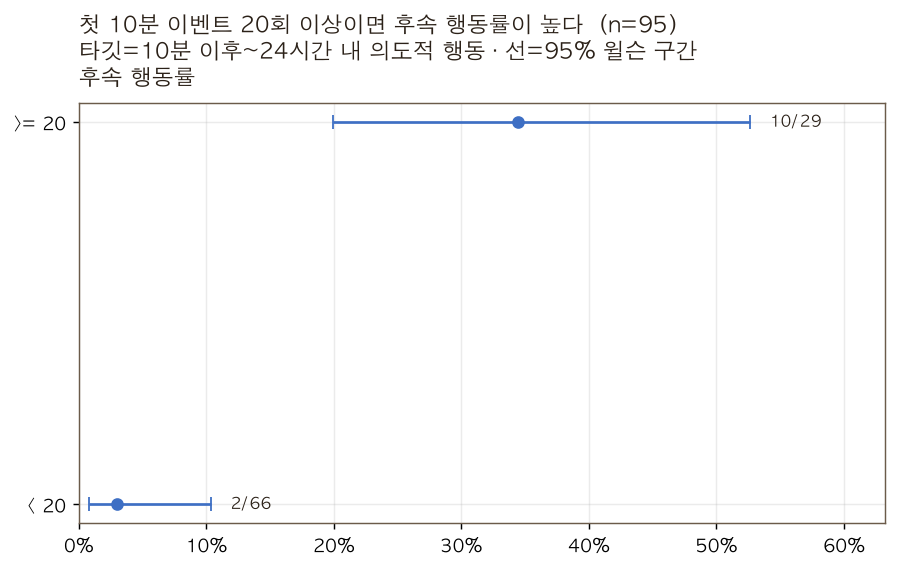

In [4]:
fig, ax = R.new(
    '첫 10분 이벤트 20회 이상이면 후속 행동률이 높다',
    len(d),
    sub='타깃=10분 이후~24시간 내 의도적 행동 · 선=95% 윌슨 구간',
    ylab='후속 행동률',
    figsize=(8, 4.2),
)
plot = split.copy()
ypos = range(len(plot))
ax.errorbar(
    plot.rate,
    list(ypos),
    xerr=[plot.rate - plot.ci_low, plot.ci_high - plot.rate],
    fmt='o',
    color=R.PALETTE[1],
    capsize=4,
)
ax.set_yticks(list(ypos), plot.segment)
ax.set_xlim(0, max(plot.ci_high) * 1.2)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i, row in enumerate(plot.itertuples()):
    ax.text(row.ci_high + 0.015, i, f'{int(row.positives)}/{int(row.devices)}', va='center', fontsize=9)
chart_split = R.save(fig, ax, 'g5_event_density_threshold_split', zero_base=False)
print(R.check(chart_split))
display(R.show(chart_split))


## 4. 임계값 민감도

20회가 우연히 예쁜 숫자인지 보려고 주변 임계값도 본다. 이 표는 새 기준을 고르는 용도가 아니라, 선택한 기준이 말이 되는지 보는 민감도다.

,threshold,flagged_devices,positives_captured,precision,recall,flagged_rate
0,5,78,12,0.153846,1.000000,0.821053
1,10,51,11,0.215686,0.916667,0.536842
2,15,40,11,0.275000,0.916667,0.421053
3,20,29,10,0.344828,0.833333,0.305263
4,30,19,8,0.421053,0.666667,0.200000
5,50,15,6,0.400000,0.500000,0.157895
6,100,7,6,0.857143,0.500000,0.073684


g5_event_density_threshold_sensitivity.png  938x620px


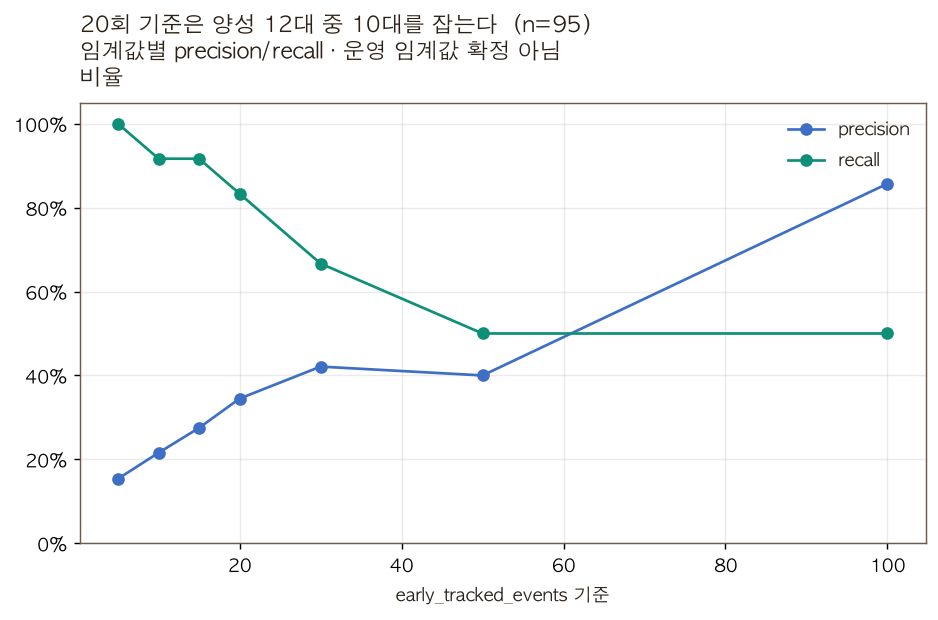

In [5]:
threshold_rows = []
for t in [5, 10, 15, 20, 30, 50, 100]:
    flag = d.early_tracked_events >= t
    positives_captured = int(((flag) & (d.y == 1)).sum())
    threshold_rows.append({
        'threshold': t,
        'flagged_devices': int(flag.sum()),
        'positives_captured': positives_captured,
        'precision': positives_captured / int(flag.sum()) if int(flag.sum()) else 0,
        'recall': positives_captured / int(d.y.sum()),
        'flagged_rate': float(flag.mean()),
    })
thresholds = pd.DataFrame(threshold_rows)
thresholds.to_csv(OUT / 'threshold_sensitivity.csv', index=False)
display(thresholds)

fig, ax = R.new(
    '20회 기준은 양성 12대 중 10대를 잡는다',
    len(d),
    sub='임계값별 precision/recall · 운영 임계값 확정 아님',
    ylab='비율',
    figsize=(8.4, 4.4),
)
ax.plot(thresholds.threshold, thresholds.precision, marker='o', color=R.PALETTE[1], label='precision')
ax.plot(thresholds.threshold, thresholds.recall, marker='o', color=R.PALETTE[2], label='recall')
ax.set_xlabel('early_tracked_events 기준')
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1))
ax.legend(frameon=False)
chart_thresholds = R.save(fig, ax, 'g5_event_density_threshold_sensitivity', zero_base=False)
print(R.check(chart_thresholds))
display(R.show(chart_thresholds))


## 5. 채널·날짜 편중 점검

신호가 전부 토스나 특정 날짜에만 있는지 확인한다. 작은 셀은 순위를 말하지 않는다.

In [6]:
channel = d.groupby(['channel_segment', 'event_density_flag'], as_index=False).agg(
    devices=('device_label', 'size'),
    positives=('y', 'sum'),
)
channel['segment'] = np.where(channel.event_density_flag, f'>= {THRESHOLD}', f'< {THRESHOLD}')
channel['rate'] = channel.positives / channel.devices
channel.to_csv(OUT / 'channel_threshold_split.csv', index=False)

by_day = d.groupby(['first_day', 'event_density_flag'], as_index=False).agg(
    devices=('device_label', 'size'),
    positives=('y', 'sum'),
)
by_day['segment'] = np.where(by_day.event_density_flag, f'>= {THRESHOLD}', f'< {THRESHOLD}')
by_day.to_csv(OUT / 'day_threshold_split.csv', index=False)

display(channel)
display(by_day)


,channel_segment,event_density_flag,devices,positives,segment,rate
0,메인·웹만,False,45,1,< 20,0.022222
1,메인·웹만,True,4,3,>= 20,0.750000
2,토스 관측,False,21,1,< 20,0.047619
3,토스 관측,True,25,7,>= 20,0.280000


,first_day,event_density_flag,devices,positives,segment
0,2026-09-04,False,20,1,< 20
1,2026-09-04,True,10,5,>= 20
2,2026-09-05,False,7,1,< 20
3,2026-09-05,True,6,2,>= 20
4,2026-09-06,False,2,0,< 20
5,2026-09-06,True,2,0,>= 20
6,2026-09-07,False,3,0,< 20
7,2026-09-08,False,2,0,< 20
8,2026-09-08,True,2,1,>= 20
9,2026-09-09,False,8,0,< 20


g5_event_density_channel_split.png  1099x631px


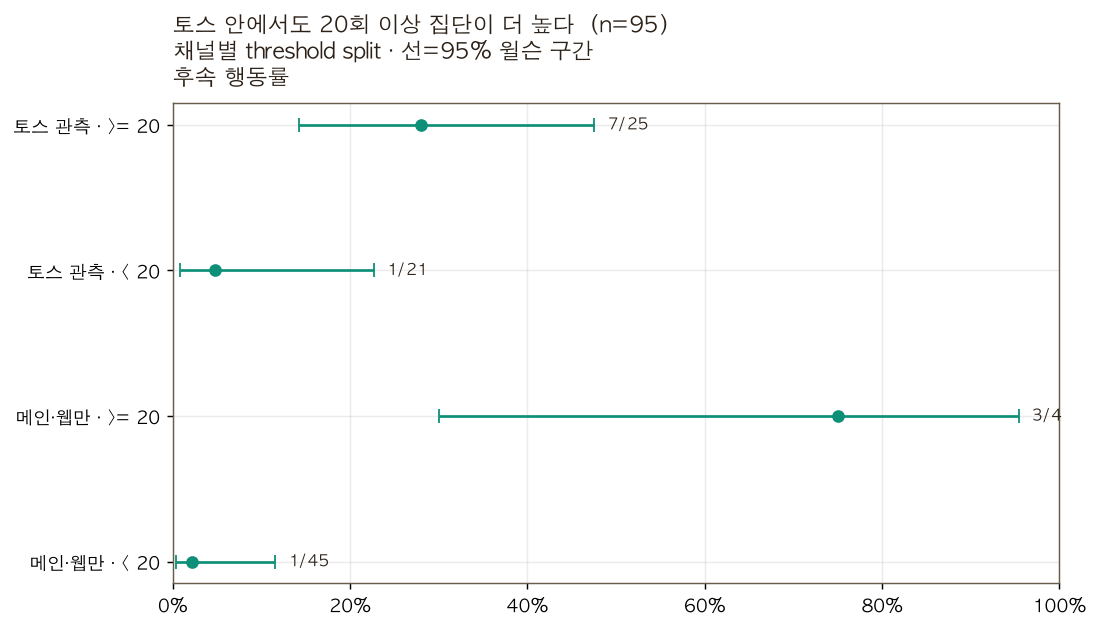

In [7]:
plot = channel.copy()
plot['label'] = plot.channel_segment + ' · ' + plot.segment
plot[['ci_low', 'ci_high']] = [wilson(int(k), int(n)) for k, n in zip(plot.positives, plot.devices)]
plot = plot.sort_values(['channel_segment', 'event_density_flag'])

fig, ax = R.new(
    '토스 안에서도 20회 이상 집단이 더 높다',
    len(d),
    sub='채널별 threshold split · 선=95% 윌슨 구간',
    ylab='후속 행동률',
    figsize=(8.8, 4.8),
)
ypos = range(len(plot))
ax.errorbar(
    plot.rate,
    list(ypos),
    xerr=[plot.rate - plot.ci_low, plot.ci_high - plot.rate],
    fmt='o',
    color=R.PALETTE[2],
    capsize=4,
)
ax.set_yticks(list(ypos), plot.label)
ax.set_xlim(0, min(1, max(plot.ci_high) * 1.2))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1))
for i, row in enumerate(plot.itertuples()):
    ax.text(row.ci_high + 0.015, i, f'{int(row.positives)}/{int(row.devices)}', va='center', fontsize=9)
chart_channel = R.save(fig, ax, 'g5_event_density_channel_split', zero_base=False)
print(R.check(chart_channel))
display(R.show(chart_channel))


## 6. 제품 해석

현재 데이터에서는 `early_tracked_events >= 20`이 “유저가 게임 루프에 들어왔다”는 강한 신호처럼 보인다. 그래서 이 집단에는 새 영역·퀘스트·낚시 같은 다음 행동 유도를 실험 후보로 둘 수 있다.

반대로 `<20` 집단은 후속 행동이 2/66뿐이다. 이들에게 콘텐츠 추천을 바로 던지기보다, 조작 안내·로딩/로그인 실패·첫 행동 유도 같은 진입 문제를 먼저 보는 쪽이 자연스럽다.

## 7. 이 숫자로 말할 수 없는 것

- 후속 행동률 차이가 곧 개입 효과는 아니다. 아직 추천을 노출한 실험이 아니다.
- `early_tracked_events`는 자동 이벤트도 포함한 추적 밀도다. 그래서 실제 조작 열의와 계측 빈도가 섞였을 수 있다.
- 9/4·9/5 양성이 많다. 시설 확장 이후에도 같은 기준이 유지되는지 재검증해야 한다.
- 표본은 기기 단위다. 사람 단위 리텐션이나 D7 리텐션으로 승격하지 않는다.

In [8]:
audit = {
    'analysis': 'g5-early-event-density-hypothesis',
    'date': '2026-09-15',
    'source': str(SRC),
    'hypothesis': 'Devices with early_tracked_events >= 20 have higher 10m-to-24h later_active rate than devices below 20.',
    'threshold': THRESHOLD,
    'n': int(len(d)),
    'positives': int(d.y.sum()),
    'high_group': {
        'devices': int(split.query("segment == '>= 20'").devices.iloc[0]),
        'positives': int(split.query("segment == '>= 20'").positives.iloc[0]),
        'rate': high_rate,
    },
    'low_group': {
        'devices': int(split.query("segment == '< 20'").devices.iloc[0]),
        'positives': int(split.query("segment == '< 20'").positives.iloc[0]),
        'rate': low_rate,
    },
    'difference_pp': diff * 100,
    'difference_ci_pp': [ci_low * 100, ci_high * 100],
    'permutation_p_value': p_value,
    'auc': auc,
    'verdict': verdict,
    'constraints': [
        'not an A/B read',
        'beta tester marked devices excluded upstream',
        'no production deployment',
        'device-level, not person-level',
    ],
}
(OUT / 'hypothesis_audit.json').write_text(json.dumps(audit, ensure_ascii=False, indent=2), encoding='utf-8')
display(Markdown('```json\n' + json.dumps(audit, ensure_ascii=False, indent=2) + '\n```'))


```json
{
  "analysis": "g5-early-event-density-hypothesis",
  "date": "2026-09-15",
  "source": "/Users/uicheol_hwang/calm_forest/ml/reports/g3_all_channel_later_targets_2026-09-15/all_channel_later_target_candidates.csv",
  "hypothesis": "Devices with early_tracked_events >= 20 have higher 10m-to-24h later_active rate than devices below 20.",
  "threshold": 20,
  "n": 95,
  "positives": 12,
  "high_group": {
    "devices": 29,
    "positives": 10,
    "rate": 0.3448275862068966
  },
  "low_group": {
    "devices": 66,
    "positives": 2,
    "rate": 0.030303030303030304
  },
  "difference_pp": 31.45245559038663,
  "difference_ci_pp": [
    14.106753812636164,
    50.05040322580645
  ],
  "permutation_p_value": 5e-05,
  "auc": 0.8830321285140562,
  "verdict": "채택 후보",
  "constraints": [
    "not an A/B read",
    "beta tester marked devices excluded upstream",
    "no production deployment",
    "device-level, not person-level"
  ]
}
```

## 8. 판정

**H-next는 채택 후보.** 현재 표본에서는 기준을 충분히 넘는다. 다음 검증은 시설 확장 이후 코호트에서 같은 기준이 유지되는지 보는 것이다. 여기서 멈춘다.